## Results

### Graphene - BC₃

* Top (shift 0)
  * Most stable Lattice constant: 5.050
  * Most stable distance: 3.432
  * Minimal free energy: -142.273
  * B-C bond:
  * C-C bond:

* Bridge (shift 1/12)
  * Most stable Lattice constant:
  * Most stable distance:
  * Minimal free energy:
  * B-C bond:
  * C-C bond:

* Hollow (shift 1/6)
  * Most stable Lattice constant:
  * Most stable distance:
  * Minimal free energy:
  * B-C bond:
  * C-C bond:

### Graphene - Borophene

* Top  (shift 0)
  * Most stable Lattice constant:
  * Most stable distance:
  * Minimal free energy:
  * B-C bond:
  * C-C bond:

* Bridge  (shift 1/12)
  * Most stable Lattice constant:
  * Most stable distance:
  * Minimal free energy:
  * B-C bond:
  * C-C bond:

* Hollow_1  (shift 1/9)
  * Most stable Lattice constant:
  * Most stable distance:
  * Minimal free energy:
  * B-C bond:
  * C-C bond:

* Hollow_2  (shift 1/6)
  * Most stable Lattice constant:
  * Most stable distance:
  * Minimal free energy:
  * B-C bond:
  * C-C bond:

### Graphene - B₄C₃

* Top (shift -1/6)
  * Most stable Lattice constant:
  * Most stable distance:
  * Minimal free energy:
  * B-C bond:
  * C-C bond:

* Bridge (shift -1/12)
  * Most stable Lattice constant:
  * Most stable distance:
  * Minimal free energy:
  * B-C bond:
  * C-C bond:

* Hollow_1 (shift -1/18)
  * Most stable Lattice constant:
  * Most stable distance:
  * Minimal free energy:
  * B-C bond:
  * C-C bond:

* Hollow_2 (shift 0)
  * Most stable Lattice constant:
  * Most stable distance:
  * Minimal free energy:
  * B-C bond:
  * C-C bond:


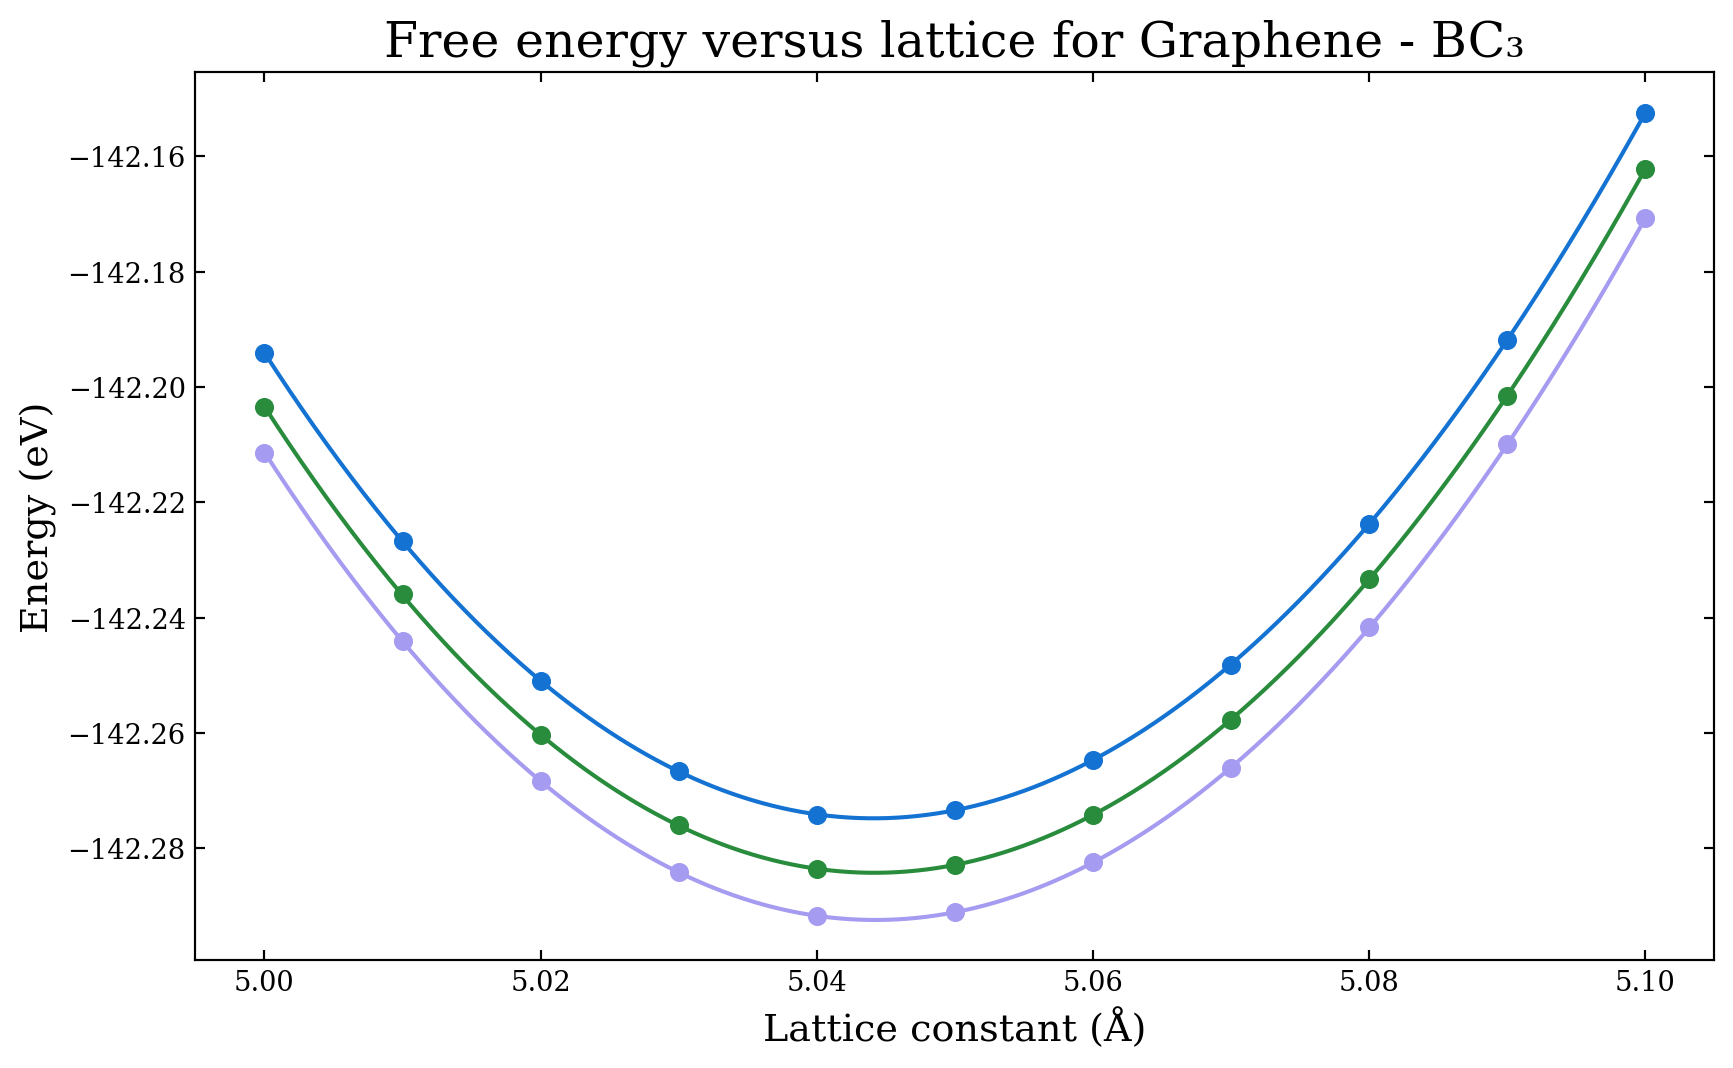

In [6]:
#### Graphene - BC3

## Read data
import numpy as np
from Store.lattice_extracting import read_lattice_distance
from Store.lattice_selecting import select_lattice

Matter = "Graphene - BC₃"

## Source data
# Top
lattice_Top, distance_Top, free_energy_Top = read_lattice_distance("0_Lattice_Twin_Lattice/A1_Graphene-BC3_Top/lattice.dat")
# Bridge
lattice_Bridge, distance_Bridge, free_energy_Bridge = read_lattice_distance("0_Lattice_Twin_Lattice/A2_Graphene-BC3_Bridge/lattice.dat")
# Hollow
lattice_Hollow, distance_Hollow, free_energy_Hollow = read_lattice_distance("0_Lattice_Twin_Lattice/A3_Graphene-BC3_Hollow/lattice.dat")
# Lattice range
lattice_range = max(max(lattice_Top), max(lattice_Bridge), max(lattice_Hollow))-min(min(lattice_Top), min(lattice_Bridge), min(lattice_Hollow))

## Fit curve
# Top
p_Top = np.polyfit(lattice_Top, free_energy_Top, 3)
f_Top = np.poly1d(p_Top)
lattice_Top_fitted = np.linspace(min(lattice_Top), max(lattice_Top), num=1000, endpoint=True)
free_energy_Top_fitted = f_Top(lattice_Top_fitted)
# Bridge
p_Bridge = np.polyfit(lattice_Bridge, free_energy_Bridge, 3)
f_Bridge  = np.poly1d(p_Bridge)
lattice_Bridge_fitted = np.linspace(min(lattice_Bridge), max(lattice_Bridge), num=1000, endpoint=True)
free_energy_Bridge_fitted = f_Bridge(lattice_Bridge_fitted)
# Hollow
p_Hollow = np.polyfit(lattice_Hollow, free_energy_Hollow, 3)
f_Hollow  = np.poly1d(p_Hollow)
lattice_Hollow_fitted = np.linspace(min(lattice_Hollow), max(lattice_Hollow), num=1000, endpoint=True)
free_energy_Hollow_fitted = f_Hollow(lattice_Hollow_fitted)

## Extrema point of source data
# Top
free_energy_Top_min = np.min(free_energy_Top)
lattice_Top_min = lattice_Top[np.argmin(free_energy_Top)]
# Bridge
free_energy_Bridge_min = np.min(free_energy_Bridge)
lattice_Bridge_min = lattice_Bridge[np.argmin(free_energy_Bridge)]
# Hollow
free_energy_Hollow_min = np.min(free_energy_Hollow)
lattice_Hollow_min = lattice_Hollow[np.argmin(free_energy_Hollow)]

## Extrema point of fitted data
# Top
f_Top_prime = f_Top.deriv()
roots_Top = f_Top_prime.r
fitted_lattice_Top_extrema = roots_Top[(roots_Top >= min(lattice_Top)) & (roots_Top <= max(lattice_Top))]
fitted_free_energy_Top_extrema = f_Top(fitted_lattice_Top_extrema)
# Bridge
f_Bridge_prime = f_Bridge.deriv()
roots_Bridge = f_Bridge_prime.r
fitted_lattice_Bridge_extrema = roots_Bridge[(roots_Bridge >= min(lattice_Bridge)) & (roots_Bridge <= max(lattice_Bridge))]
fitted_free_energy_Bridge_extrema = f_Bridge(fitted_lattice_Bridge_extrema)
# Hollow
f_Hollow_prime = f_Hollow.deriv()
roots_Hollow = f_Hollow_prime.r
fitted_lattice_Hollow_extrema = roots_Hollow[(roots_Hollow >= min(lattice_Hollow)) & (roots_Hollow <= max(lattice_Hollow))]
fitted_free_energy_Hollow_extrema = f_Hollow(fitted_lattice_Hollow_extrema)

## Plot
import matplotlib.pyplot as plt

plt.figure(dpi=196, figsize=(10,6))
params = {"text.usetex": False, "font.family": "serif", "mathtext.fontset": "cm",
          "axes.titlesize": 18, "axes.labelsize": 14, "figure.facecolor": "w"}
plt.rcParams.update(params)
plt.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)
plt.title(f"Free energy versus lattice for {Matter}"); plt.xlabel(r"Lattice constant (Å)"); plt.ylabel(r"Energy (eV)")

# Source data: Top
plt.scatter(lattice_Top, free_energy_Top, color="#1473D2", label="Source data: Top", zorder=2)
# Source data: Bridge
plt.scatter(lattice_Bridge, free_energy_Bridge, color="#288C3C", label="Source data: Bridge", zorder=2)
# Source data: Hollow
plt.scatter(lattice_Hollow, free_energy_Hollow, color="#A59BF0", label="Source data: Hollow", zorder=2)

# Fitted data: top
plt.plot(lattice_Top_fitted, free_energy_Top_fitted, color="#1473D2", label="Fitted data: Top", zorder=1)
# Fitted data: Bridge
plt.plot(lattice_Bridge_fitted, free_energy_Bridge_fitted, color="#288C3C", label="Fitted data: Bridge", zorder=1)
# Fitted data: Hollow
plt.plot(lattice_Hollow_fitted, free_energy_Hollow_fitted, color="#A59BF0", label="Fitted data: Hollow", zorder=1)


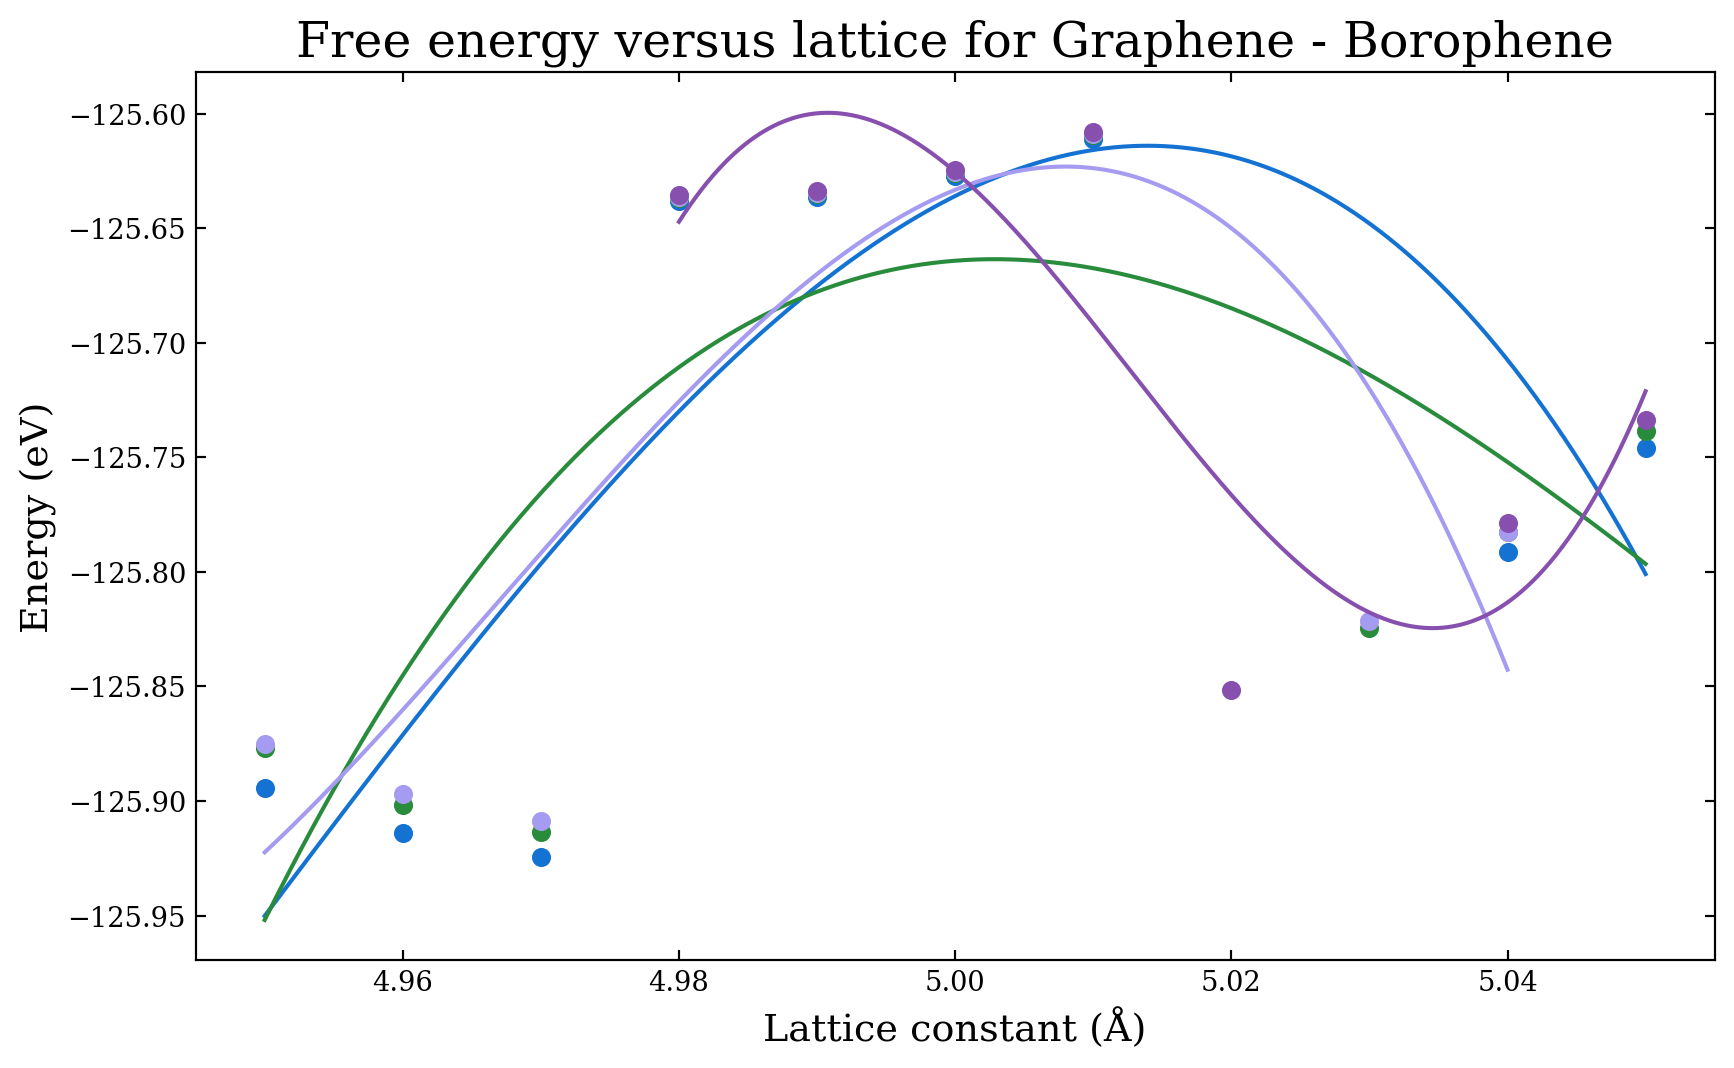

In [4]:
#### Graphene - Borophene

Matter = "Graphene - Borophene"

## Source data
# Top
lattice_Top, distance_Top, free_energy_Top = read_lattice_distance("0_Lattice_Twin_Lattice/B1_Graphene-Borophene_Top/lattice.dat")
# Bridge
lattice_Bridge, distance_Bridge, free_energy_Bridge = read_lattice_distance("0_Lattice_Twin_Lattice/B2_Graphene-Borophene_Bridge/lattice.dat")
# Hollow 1
lattice_Hollow_1, distance_Hollow_1, free_energy_Hollow_1 = read_lattice_distance("0_Lattice_Twin_Lattice/B3_Graphene-Borophene_Hollow_1/lattice.dat")
# Hollow 2
lattice_Hollow_2, distance_Hollow_2, free_energy_Hollow_2 = read_lattice_distance("0_Lattice_Twin_Lattice/B4_Graphene-Borophene_Hollow_2/lattice.dat")
# Lattice range
lattice_range = max(max(lattice_Top), max(lattice_Bridge), max(lattice_Hollow_1), max(lattice_Hollow_2))-min(min(lattice_Top), min(lattice_Bridge), min(lattice_Hollow_1), min(lattice_Hollow_2))

## Fit curve
# Top
p_Top = np.polyfit(lattice_Top, free_energy_Top, 3)
f_Top = np.poly1d(p_Top)
lattice_Top_fitted = np.linspace(min(lattice_Top), max(lattice_Top), num=1000, endpoint=True)
free_energy_Top_fitted = f_Top(lattice_Top_fitted)
# Bridge
p_Bridge = np.polyfit(lattice_Bridge, free_energy_Bridge, 3)
f_Bridge  = np.poly1d(p_Bridge)
lattice_Bridge_fitted = np.linspace(min(lattice_Bridge), max(lattice_Bridge), num=1000, endpoint=True)
free_energy_Bridge_fitted = f_Bridge(lattice_Bridge_fitted)
# Hollow 1
p_Hollow_1 = np.polyfit(lattice_Hollow_1, free_energy_Hollow_1, 3)
f_Hollow_1  = np.poly1d(p_Hollow_1)
lattice_Hollow_1_fitted = np.linspace(min(lattice_Hollow_1), max(lattice_Hollow_1), num=1000, endpoint=True)
free_energy_Hollow_1_fitted = f_Hollow_1(lattice_Hollow_1_fitted)
# Hollow 2
p_Hollow_2 = np.polyfit(lattice_Hollow_2, free_energy_Hollow_2, 3)
f_Hollow_2  = np.poly1d(p_Hollow_2)
lattice_Hollow_2_fitted = np.linspace(min(lattice_Hollow_2), max(lattice_Hollow_2), num=1000, endpoint=True)
free_energy_Hollow_2_fitted = f_Hollow_2(lattice_Hollow_2_fitted)

## Extrema point of source data
# Top
free_energy_Top_min = np.min(free_energy_Top)
lattice_Top_min = lattice_Top[np.argmin(free_energy_Top)]
# Bridge
free_energy_Bridge_min = np.min(free_energy_Bridge)
lattice_Bridge_min = lattice_Bridge[np.argmin(free_energy_Bridge)]
# Hollow_1
free_energy_Hollow_1_min = np.min(free_energy_Hollow_1)
lattice_Hollow_1_min = lattice_Hollow_1[np.argmin(free_energy_Hollow_1)]
# Hollow_2
free_energy_Hollow_2_min = np.min(free_energy_Hollow_2)
lattice_Hollow_2_min = lattice_Hollow_2[np.argmin(free_energy_Hollow_2)]

## Extrema point of fitted data
# Top
f_Top_prime = f_Top.deriv()
roots_Top = f_Top_prime.r
fitted_lattice_Top_extrema = roots_Top[(roots_Top >= min(lattice_Top)) & (roots_Top <= max(lattice_Top))]
fitted_free_energy_Top_extrema = f_Top(fitted_lattice_Top_extrema)
# Bridge
f_Bridge_prime = f_Bridge.deriv()
roots_Bridge = f_Bridge_prime.r
fitted_lattice_Bridge_extrema = roots_Bridge[(roots_Bridge >= min(lattice_Bridge)) & (roots_Bridge <= max(lattice_Bridge))]
fitted_free_energy_Bridge_extrema = f_Bridge(fitted_lattice_Bridge_extrema)
# Hollow 1
f_Hollow_1_prime = f_Hollow_1.deriv()
roots_Hollow_1 = f_Hollow_1_prime.r
fitted_lattice_Hollow_1_extrema = roots_Hollow_1[(roots_Hollow_1 >= min(lattice_Hollow_1)) & (roots_Hollow_1 <= max(lattice_Hollow_1))]
fitted_free_energy_Hollow_1_extrema = f_Hollow_1(fitted_lattice_Hollow_1_extrema)
# Hollow 2
f_Hollow_2_prime = f_Hollow_2.deriv()
roots_Hollow_2 = f_Hollow_2_prime.r
fitted_lattice_Hollow_2_extrema = roots_Hollow_2[(roots_Hollow_2 >= min(lattice_Hollow_2)) & (roots_Hollow_2 <= max(lattice_Hollow_2))]
fitted_free_energy_Hollow_2_extrema = f_Hollow_2(fitted_lattice_Hollow_2_extrema)

## Plot
import matplotlib.pyplot as plt

plt.figure(dpi=196, figsize=(10,6))
params = {"text.usetex": False, "font.family": "serif", "mathtext.fontset": "cm",
          "axes.titlesize": 18, "axes.labelsize": 14, "figure.facecolor": "w"}
plt.rcParams.update(params)
plt.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)
plt.title(f"Free energy versus lattice for {Matter}"); plt.xlabel(r"Lattice constant (Å)"); plt.ylabel(r"Energy (eV)")

# Source data: Top
plt.scatter(lattice_Top, free_energy_Top, color="#1473D2", label="Source data: Top", zorder=2)
# Source data: Bridge
plt.scatter(lattice_Bridge, free_energy_Bridge, color="#288C3C", label="Source data: Bridge", zorder=2)
# Source data: Hollow 1
plt.scatter(lattice_Hollow_1, free_energy_Hollow_1, color="#A59BF0", label="Source data: Hollow 1", zorder=2)
# Source data: Hollow 2
plt.scatter(lattice_Hollow_2, free_energy_Hollow_2, color="#8750AF", label="Source data: Hollow 2", zorder=2)

# Fitted data: top
plt.plot(lattice_Top_fitted, free_energy_Top_fitted, color="#1473D2", label="Fitted data: Top", zorder=1)
# Fitted data: Bridge
plt.plot(lattice_Bridge_fitted, free_energy_Bridge_fitted, color="#288C3C", label="Fitted data: Bridge", zorder=1)
# Fitted data: Hollow 1
plt.plot(lattice_Hollow_1_fitted, free_energy_Hollow_1_fitted, color="#A59BF0", label="Fitted data: Hollow 1", zorder=1)
# Fitted data: Hollow 2
plt.plot(lattice_Hollow_2_fitted, free_energy_Hollow_2_fitted, color="#8750AF", label="Fitted data: Hollow 2", zorder=1)


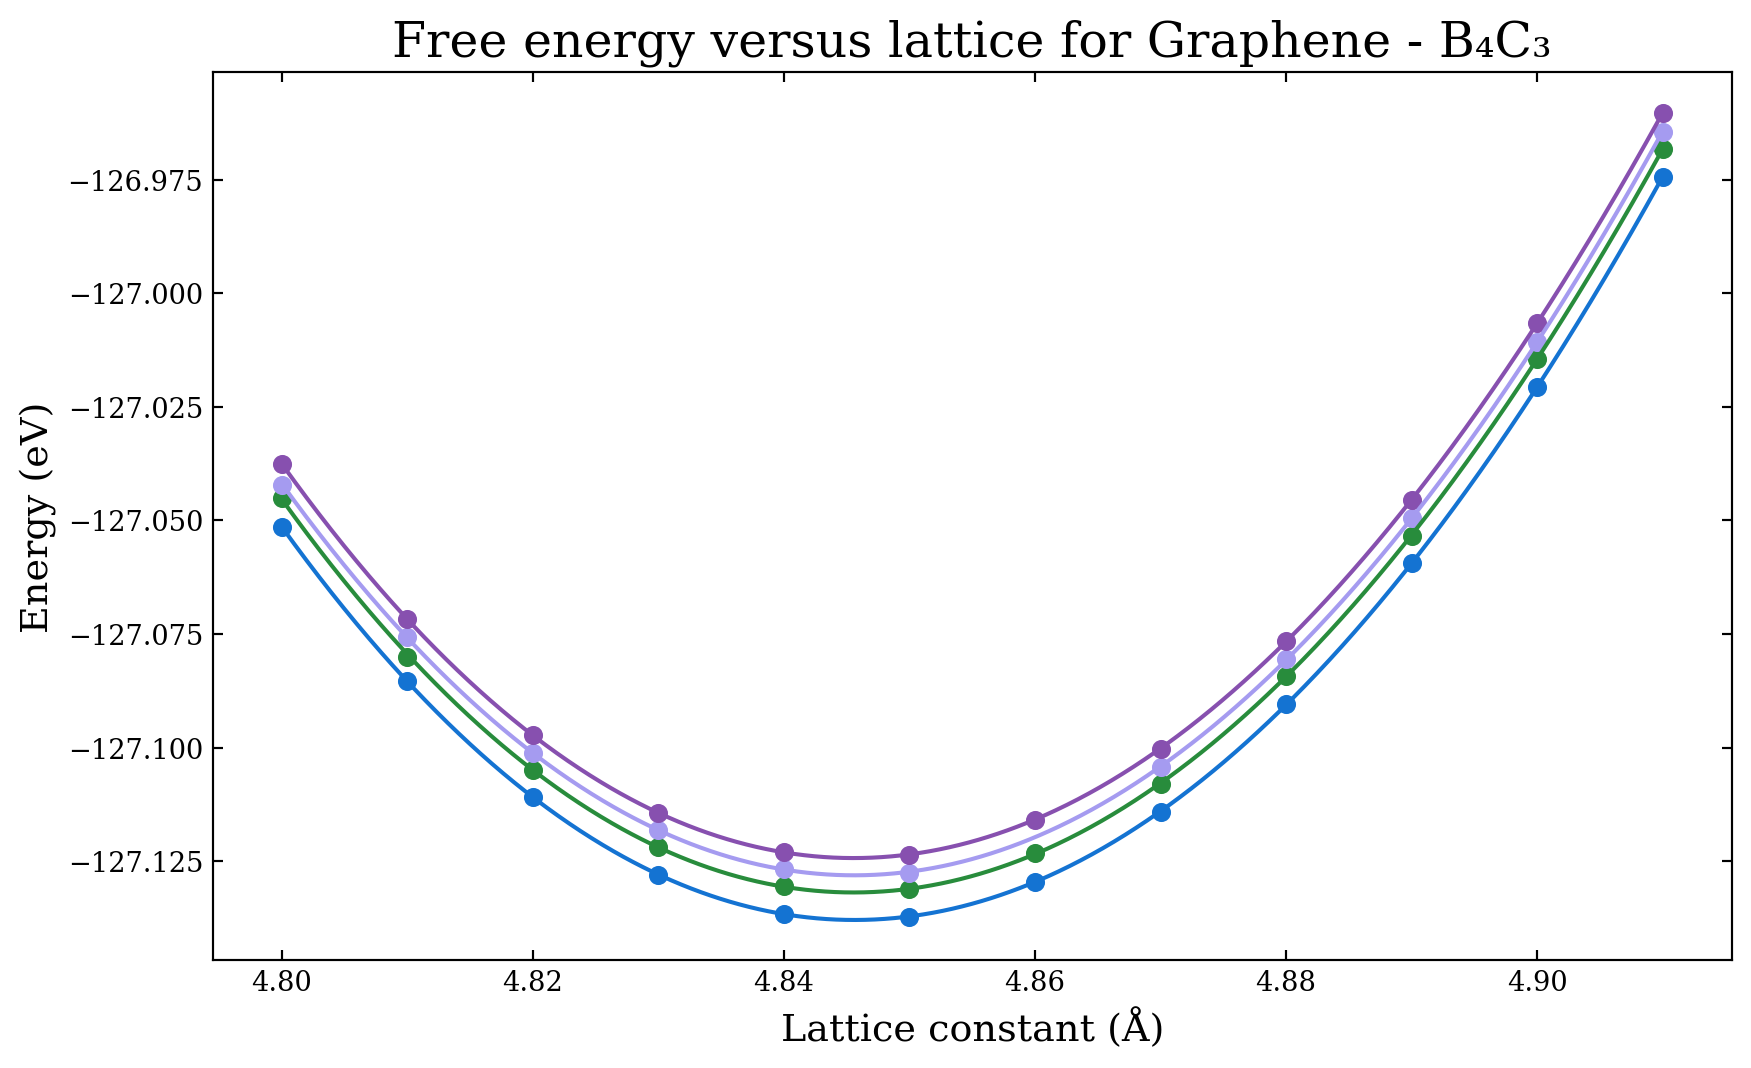

In [5]:
#### Graphene - B4C3

Matter = "Graphene - B₄C₃"

## Source data
# Top
lattice_Top, distance_Top, free_energy_Top = read_lattice_distance("0_Lattice_Twin_Lattice/C1_Graphene-B4C3_Top/lattice.dat")
# Bridge
lattice_Bridge, distance_Bridge, free_energy_Bridge = read_lattice_distance("0_Lattice_Twin_Lattice/C2_Graphene-B4C3_Bridge/lattice.dat")
# Hollow 1
lattice_Hollow_1, distance_Hollow_1, free_energy_Hollow_1 = read_lattice_distance("0_Lattice_Twin_Lattice/C3_Graphene-B4C3_Hollow_1/lattice.dat")
# Hollow 2
lattice_Hollow_2, distance_Hollow_2, free_energy_Hollow_2 = read_lattice_distance("0_Lattice_Twin_Lattice/C4_Graphene-B4C3_Hollow_2/lattice.dat")
# Lattice range
lattice_range = max(max(lattice_Top), max(lattice_Bridge), max(lattice_Hollow_1), max(lattice_Hollow_2))-min(min(lattice_Top), min(lattice_Bridge), min(lattice_Hollow_1), min(lattice_Hollow_2))

## Fit curve
# Top
p_Top = np.polyfit(lattice_Top, free_energy_Top, 3)
f_Top = np.poly1d(p_Top)
lattice_Top_fitted = np.linspace(min(lattice_Top), max(lattice_Top), num=1000, endpoint=True)
free_energy_Top_fitted = f_Top(lattice_Top_fitted)
# Bridge
p_Bridge = np.polyfit(lattice_Bridge, free_energy_Bridge, 3)
f_Bridge  = np.poly1d(p_Bridge)
lattice_Bridge_fitted = np.linspace(min(lattice_Bridge), max(lattice_Bridge), num=1000, endpoint=True)
free_energy_Bridge_fitted = f_Bridge(lattice_Bridge_fitted)
# Hollow 1
p_Hollow_1 = np.polyfit(lattice_Hollow_1, free_energy_Hollow_1, 3)
f_Hollow_1  = np.poly1d(p_Hollow_1)
lattice_Hollow_1_fitted = np.linspace(min(lattice_Hollow_1), max(lattice_Hollow_1), num=1000, endpoint=True)
free_energy_Hollow_1_fitted = f_Hollow_1(lattice_Hollow_1_fitted)
# Hollow 2
p_Hollow_2 = np.polyfit(lattice_Hollow_2, free_energy_Hollow_2, 3)
f_Hollow_2  = np.poly1d(p_Hollow_2)
lattice_Hollow_2_fitted = np.linspace(min(lattice_Hollow_2), max(lattice_Hollow_2), num=1000, endpoint=True)
free_energy_Hollow_2_fitted = f_Hollow_2(lattice_Hollow_2_fitted)

## Extrema point of source data
# Top
free_energy_Top_min = np.min(free_energy_Top)
lattice_Top_min = lattice_Top[np.argmin(free_energy_Top)]
# Bridge
free_energy_Bridge_min = np.min(free_energy_Bridge)
lattice_Bridge_min = lattice_Bridge[np.argmin(free_energy_Bridge)]
# Hollow_1
free_energy_Hollow_1_min = np.min(free_energy_Hollow_1)
lattice_Hollow_1_min = lattice_Hollow_1[np.argmin(free_energy_Hollow_1)]
# Hollow_2
free_energy_Hollow_2_min = np.min(free_energy_Hollow_2)
lattice_Hollow_2_min = lattice_Hollow_2[np.argmin(free_energy_Hollow_2)]

## Extrema point of fitted data
# Top
f_Top_prime = f_Top.deriv()
roots_Top = f_Top_prime.r
fitted_lattice_Top_extrema = roots_Top[(roots_Top >= min(lattice_Top)) & (roots_Top <= max(lattice_Top))]
fitted_free_energy_Top_extrema = f_Top(fitted_lattice_Top_extrema)
# Bridge
f_Bridge_prime = f_Bridge.deriv()
roots_Bridge = f_Bridge_prime.r
fitted_lattice_Bridge_extrema = roots_Bridge[(roots_Bridge >= min(lattice_Bridge)) & (roots_Bridge <= max(lattice_Bridge))]
fitted_free_energy_Bridge_extrema = f_Bridge(fitted_lattice_Bridge_extrema)
# Hollow 1
f_Hollow_1_prime = f_Hollow_1.deriv()
roots_Hollow_1 = f_Hollow_1_prime.r
fitted_lattice_Hollow_1_extrema = roots_Hollow_1[(roots_Hollow_1 >= min(lattice_Hollow_1)) & (roots_Hollow_1 <= max(lattice_Hollow_1))]
fitted_free_energy_Hollow_1_extrema = f_Hollow_1(fitted_lattice_Hollow_1_extrema)
# Hollow 2
f_Hollow_2_prime = f_Hollow_2.deriv()
roots_Hollow_2 = f_Hollow_2_prime.r
fitted_lattice_Hollow_2_extrema = roots_Hollow_2[(roots_Hollow_2 >= min(lattice_Hollow_2)) & (roots_Hollow_2 <= max(lattice_Hollow_2))]
fitted_free_energy_Hollow_2_extrema = f_Hollow_2(fitted_lattice_Hollow_2_extrema)

## Plot
import matplotlib.pyplot as plt

plt.figure(dpi=196, figsize=(10,6))
params = {"text.usetex": False, "font.family": "serif", "mathtext.fontset": "cm",
          "axes.titlesize": 18, "axes.labelsize": 14, "figure.facecolor": "w"}
plt.rcParams.update(params)
plt.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)
plt.title(f"Free energy versus lattice for {Matter}"); plt.xlabel(r"Lattice constant (Å)"); plt.ylabel(r"Energy (eV)")

# Source data: Top
plt.scatter(lattice_Top, free_energy_Top, color="#1473D2", label="Source data: Top", zorder=2)
# Source data: Bridge
plt.scatter(lattice_Bridge, free_energy_Bridge, color="#288C3C", label="Source data: Bridge", zorder=2)
# Source data: Hollow 1
plt.scatter(lattice_Hollow_1, free_energy_Hollow_1, color="#A59BF0", label="Source data: Hollow 1", zorder=2)
# Source data: Hollow 2
plt.scatter(lattice_Hollow_2, free_energy_Hollow_2, color="#8750AF", label="Source data: Hollow 2", zorder=2)

# Fitted data: top
plt.plot(lattice_Top_fitted, free_energy_Top_fitted, color="#1473D2", label="Fitted data: Top", zorder=1)
# Fitted data: Bridge
plt.plot(lattice_Bridge_fitted, free_energy_Bridge_fitted, color="#288C3C", label="Fitted data: Bridge", zorder=1)
# Fitted data: Hollow 1
plt.plot(lattice_Hollow_1_fitted, free_energy_Hollow_1_fitted, color="#A59BF0", label="Fitted data: Hollow 1", zorder=1)
# Fitted data: Hollow 2
plt.plot(lattice_Hollow_2_fitted, free_energy_Hollow_2_fitted, color="#8750AF", label="Fitted data: Hollow 2", zorder=1)
